In [1]:
import os
import math
import time
import sys
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
from tqdm import trange, tqdm
import matplotlib.pyplot as plt
%matplotlib inline
import torch
import torch.nn.functional as F  
from torch.utils.tensorboard import SummaryWriter

from Utils.CADTensorGenerator import CADTensorGenerator
from Decoder_CLasses.ContinuousVoronoiDecoder import ContinuousVoronoiDecoder
from Utils.CADDomainVisualizer import CADDomainVisualizer
from Utils.CADVisualizer   import CADVisualizer
from neuraltomo_fem import run_fem_loss
from problems.ThickenShell import ThickenShell

import pyvista as pv


# ---- Reproducibility (recommended for D_params comparisons) ----
SEED = 20
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

BASE = Path(__file__).parent if "__file__" in globals() else Path.cwd()
print("Code Directory:", BASE)
TesPartsDir = BASE / "Testparts" 
print("Test Step files Directory:", TesPartsDir)


if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("device:", device)
# -------- PYVISTA BACKEND --------
def setup_pyvista(device):
    is_mac = sys.platform == "darwin"

    # Mac + MPS: prefer static to avoid VTK/trame hangs
    if is_mac :
        pv.OFF_SCREEN = True
        pv.set_jupyter_backend("static")
        backend = "static"
    else:
        try:
            pv.set_jupyter_backend("trame")
            backend = "trame"
        except Exception:
            pv.OFF_SCREEN = True
            pv.set_jupyter_backend("static")
            backend = "static"

    print(f"PyVista backend: {backend}")

setup_pyvista(device)


Code Directory: /home/arash/HVD_SFK/HVD_SeedsBase
Test Step files Directory: /home/arash/HVD_SFK/HVD_SeedsBase/Testparts
device: cuda
PyVista backend: trame



=== Active Face Info ===
XYZ bounds:
  X: [-0.000000, 10.000000]  span=10.000000
  Y: [-0.127468, 2.100919]  span=2.228387
  Z: [-2.032622, 1.938721]  span=3.971343

UV bounds:
  U: [-0.039832, 3.264132]
  V: [-5.000000, 5.000000]

Periodic:
  U periodic: False
  V periodic: False



Widget(value='<iframe src="http://localhost:39773/index.html?ui=P_0x7b6a844fbeb0_0&reconnect=auto" class="pyvi…

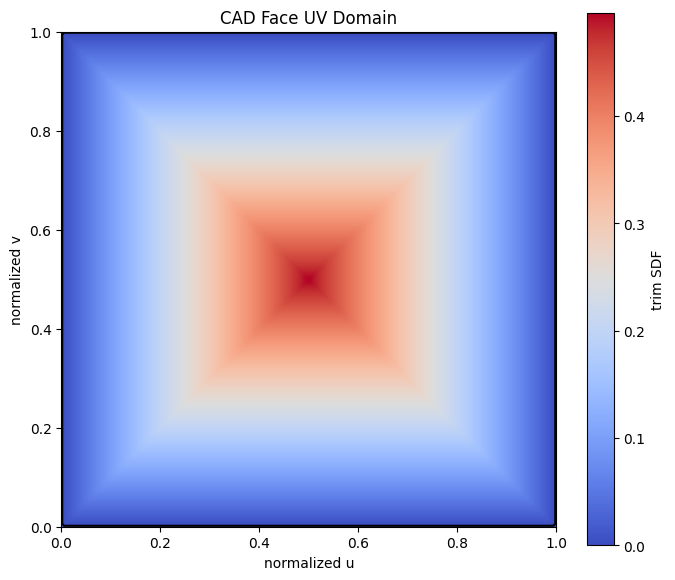

In [2]:
viz = CADVisualizer()
# Laoding model and extracting mesh and tensors as input
FreeFormSurf1  = TesPartsDir / "FreeFormCrv1.stp"
FreeFormSurf2A = TesPartsDir / "FreeFormSurf2A.STEP"
FreeFormSurf3 = TesPartsDir / "FreeForm3.stp"
ConeTaped = TesPartsDir / "ConeTaped.stp"
FreeFormCLosed = TesPartsDir / "FreeFormClosed.stp"
Planar = TesPartsDir / "Planar.stp"
YachtBodypart  = TesPartsDir / "YachtBodypart.stp"
CircularSurf1  = TesPartsDir / "CircularSurf1.stp"
Cube           = TesPartsDir / "Cube.stp"
CircularSur2   = TesPartsDir / "CircularSur2.stp"
Conic          = TesPartsDir / "Conic.stp"
CircularHoles  = TesPartsDir / "CircularHoles.stp"
FullCylinder   = TesPartsDir / "FullCylinder.stp"
Sphere         = TesPartsDir / "Sphere.stp"
SphereTap      = TesPartsDir / "SphereTap.stp"
Tidebottle     = TesPartsDir / "Tidebottle.STEP"
FreeFormSurf4 = TesPartsDir / "FreeForm4.stp"
FreeFormBench = TesPartsDir / "FreeFormBench.stp"
FreeSharp1 = TesPartsDir / "FreeSharp1.stp"
FreeSharp2 = TesPartsDir / "FreeSharp2.stp"
SeatBr = TesPartsDir / "SeatBr.stp"
MouseBot = TesPartsDir / "MouseBot.stp"

shape_path = CircularSurf1

Face_Cad = CADTensorGenerator(
    device=device,
    seed_domain_mask_res=128,
)
domain = Face_Cad.generate_from_file(shape_path)
Face_Cad.print_face_info()
viz = CADDomainVisualizer(Face_Cad)
viz.plot_uv_domain()
viz.show_3d(res_u=200, res_v=200, show_edges=True)


In [3]:
def random_seeds_min_dist(N, min_dist=0.08, seed=1, max_tries=10000, device="cpu"):
    torch.manual_seed(seed)

    seeds = []
    tries = 0

    while len(seeds) < N and tries < max_tries:
        p = torch.rand(2, device=device)

        if len(seeds) == 0:
            seeds.append(p)
        else:
            current = torch.stack(seeds, dim=0)
            d = torch.linalg.norm(current - p[None, :], dim=-1)

            if d.min() >= min_dist:
                seeds.append(p)

        tries += 1

    if len(seeds) < N:
        raise RuntimeError(
            f"Could only generate {len(seeds)} seeds with min_dist={min_dist}."
        )

    return torch.stack(seeds, dim=0)

grad finite: tensor(True)


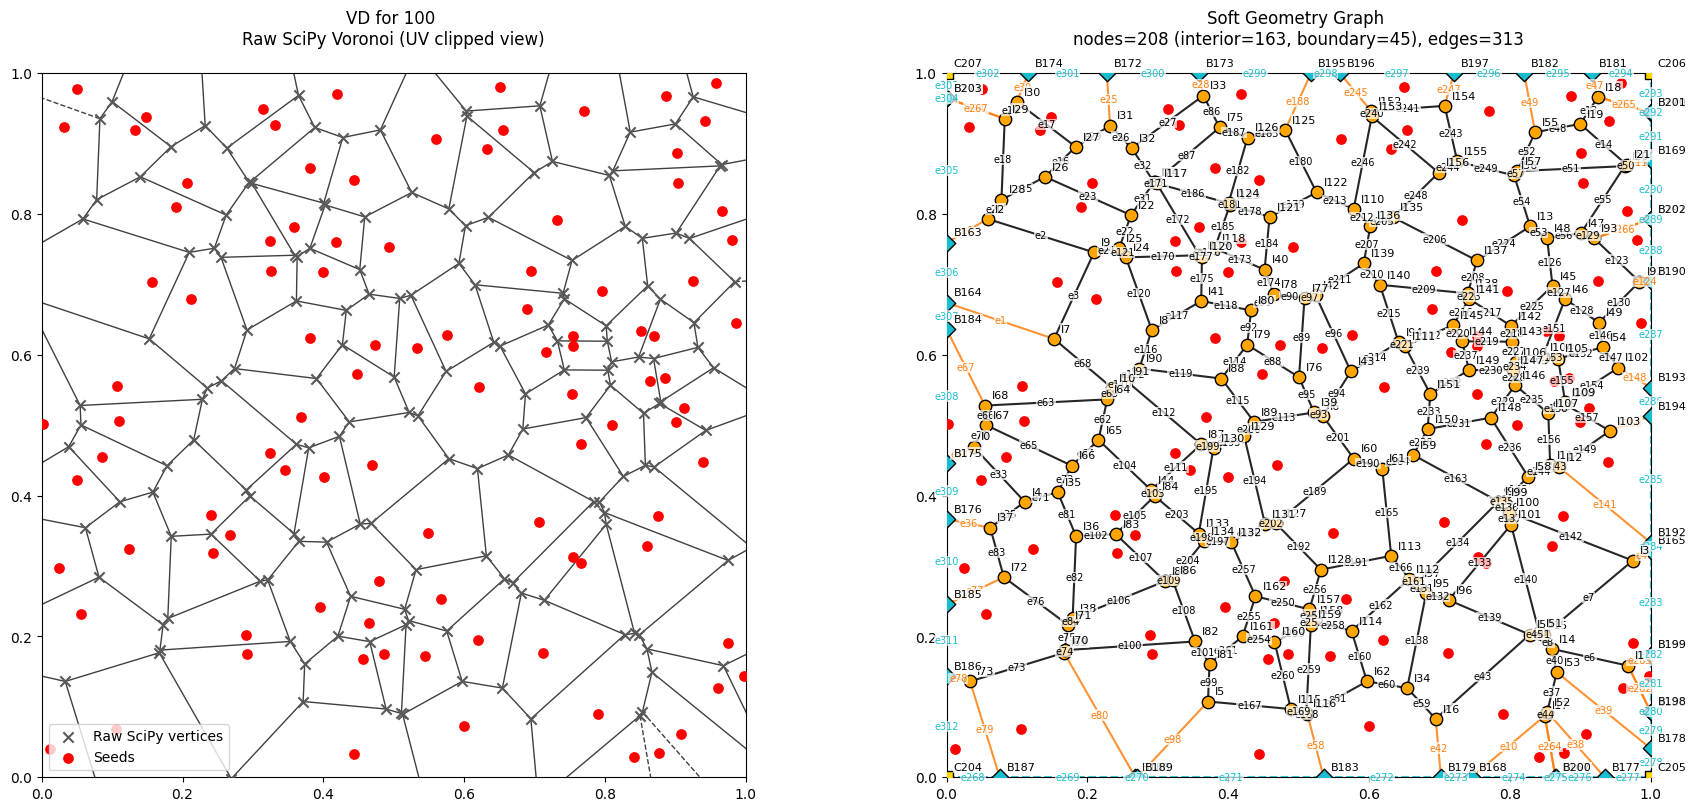

grad finite: tensor(True)


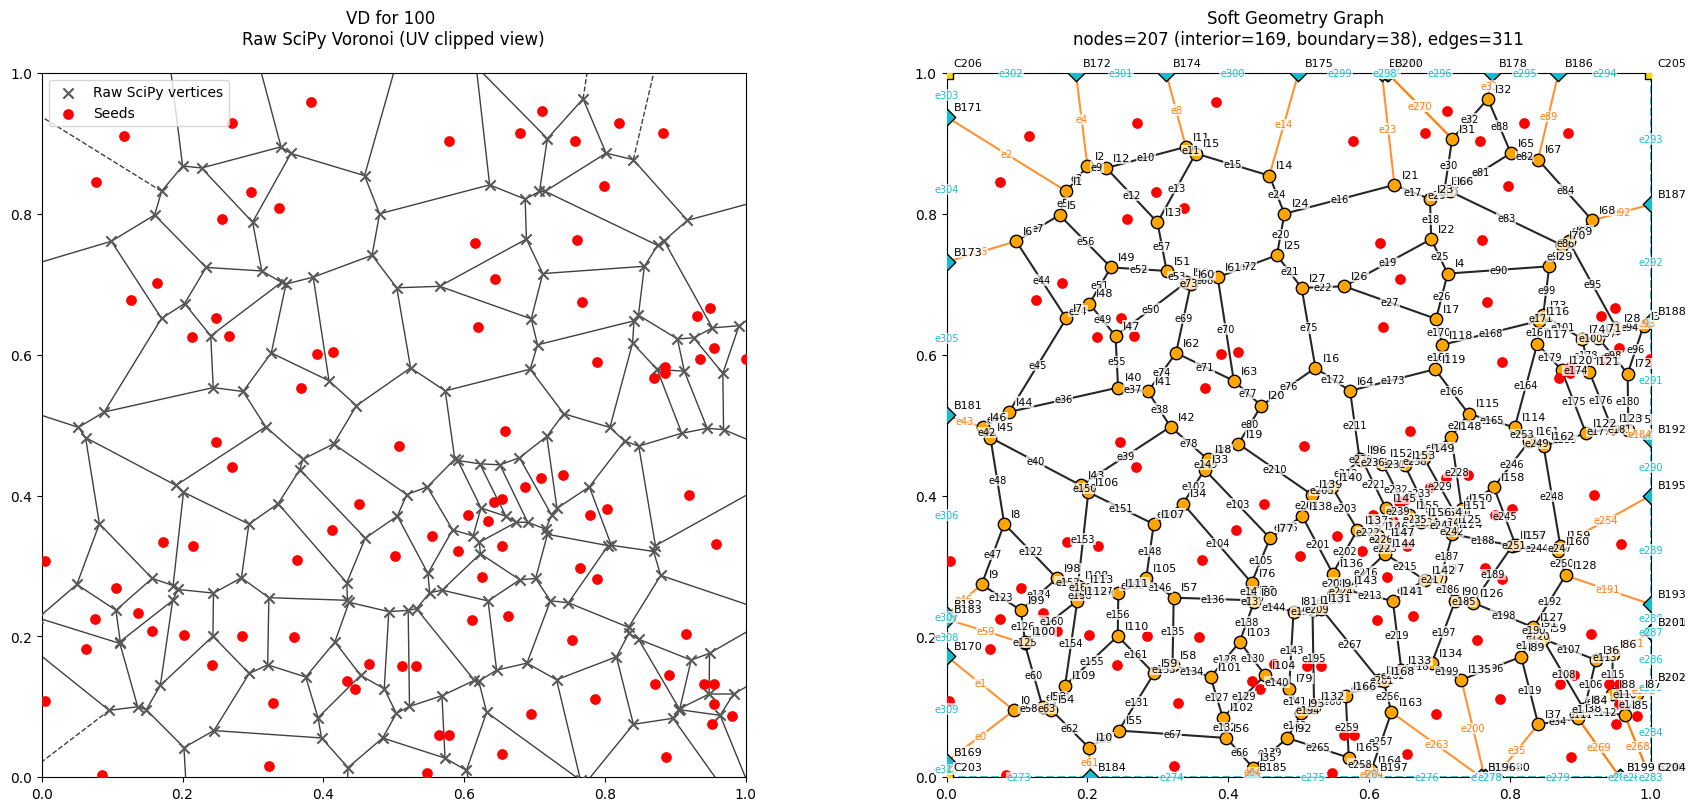

grad finite: tensor(True)


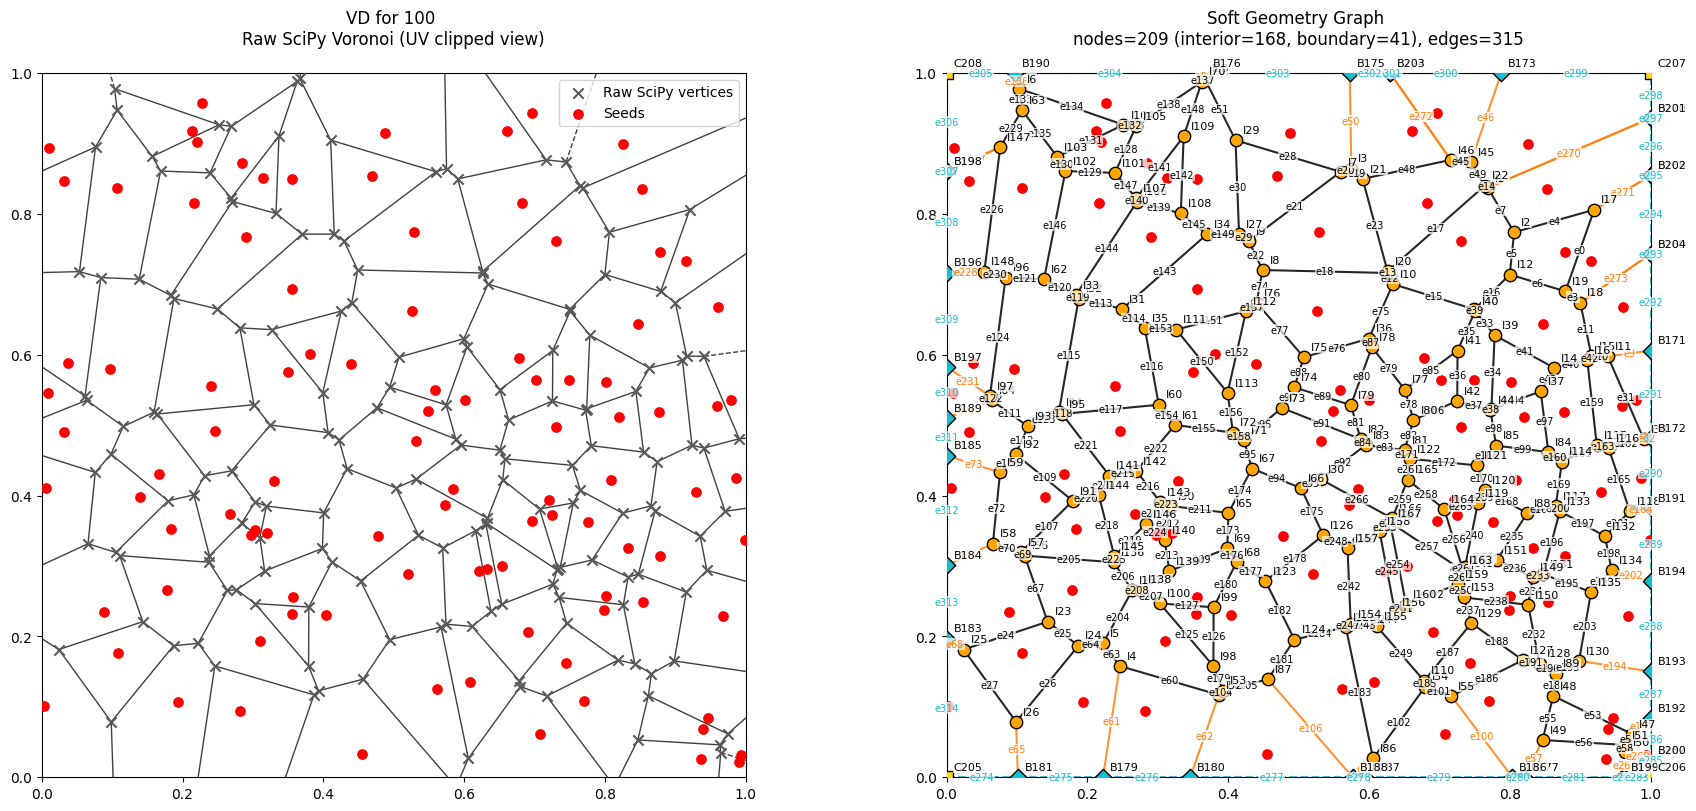

In [4]:
dec = ContinuousVoronoiDecoder(
    return_xyz=False,
    min_area=1e-3,
    duplicate_merge_sigma = 0.005,
    tau_area=1e-4,
    min_seed_dist=0.01,
    tau_close=0.001,
)

for i in range(1,4):
    N=100
    seeds = random_seeds_min_dist(
        N=N,
        min_dist=0.008,
        seed=i*21,
        device="cpu",
    )

    seeds = seeds.detach().clone().requires_grad_(True)

    out = dec(
        seeds,
        topology_mode="scipy",
        return_xyz=False,
    )

    graph = out["graph"]

    # print("interior vertices:", out["vertices_uv"].shape)
    # print("finite edges:", out["edges"]["edge_index"].shape)
    # print("boundary rays:", out["boundary_rays"].shape)

    # print("graph nodes:", graph["nodes_uv"].shape)
    # print("graph edges:", graph["edge_index"].shape)
    # print("node type:", graph["node_type"])
    # print("boundary nodes:", graph["num_boundary_nodes"])


    loss = graph["nodes_uv"].sum()
    loss.backward()
    print("grad finite:", torch.isfinite(seeds.grad).all())

    # dec.plot_generatedN_graph_debug(seeds,out,Face_Cad,True,True,12,False)
    dec.plot_scipy_vs_generated_graph(seeds,out,Face_Cad,True,True,8,False);

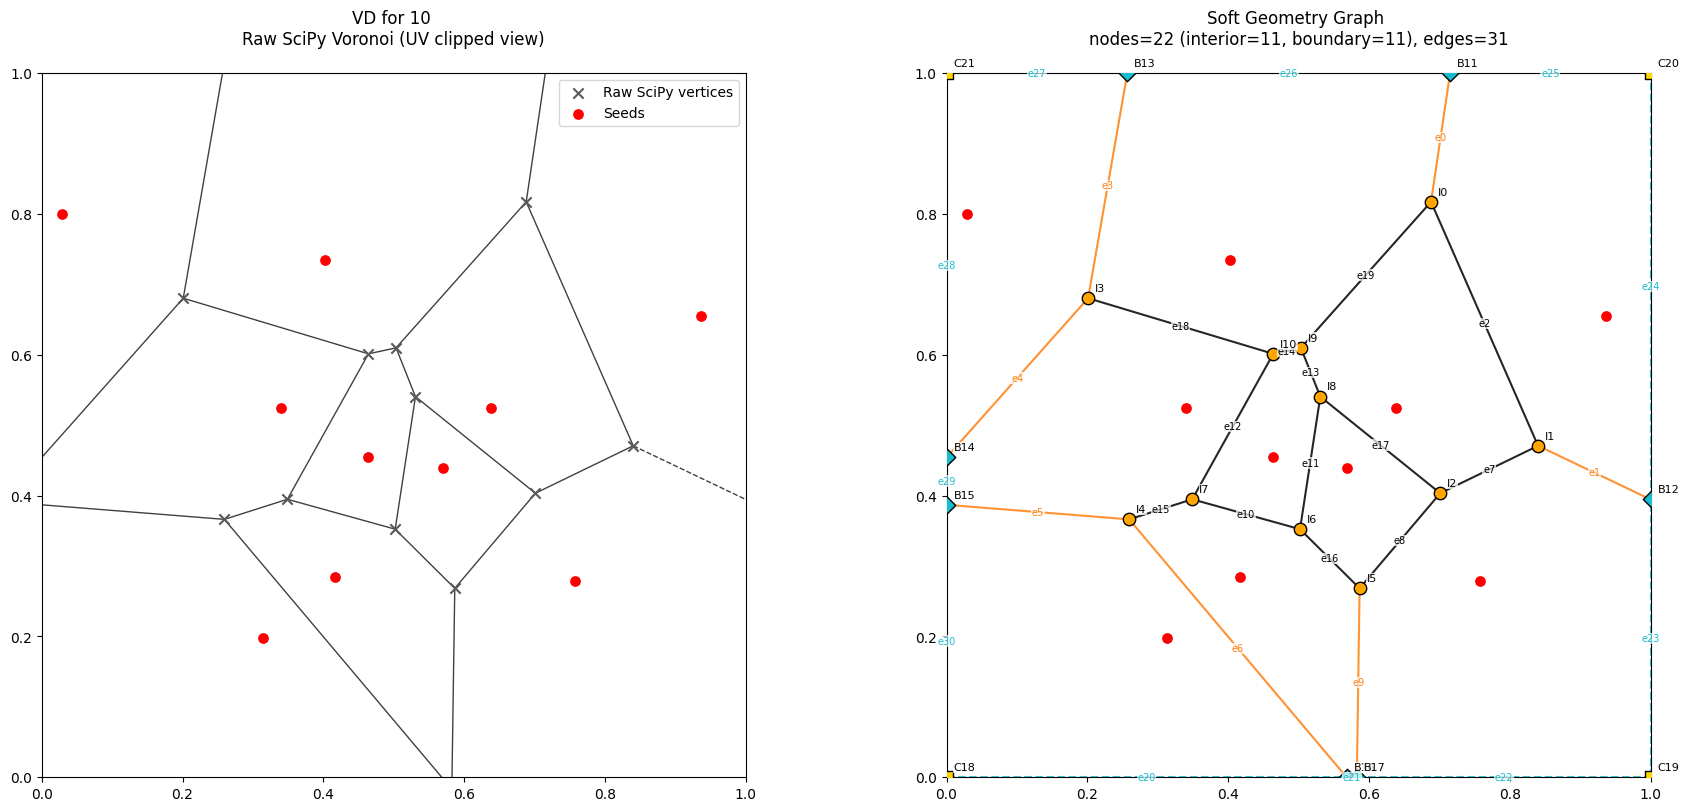


Node table
node_id  node_type       u          v      degree      alpha
      0  interior    0.688177   0.817363     3.000   1.000000
      1  interior    0.840212   0.470858     3.000   1.000000
      2  interior    0.701211   0.403462     3.000   1.000000
      3  interior    0.201040   0.680480     3.000   1.000000
      4  interior    0.259475   0.366343     3.000   1.000000
      5  interior    0.586714   0.268375     3.000   1.000000
      6  interior    0.502065   0.352396     3.000   1.000000
      7  interior    0.348962   0.394878     3.000   1.000000
      8  interior    0.530884   0.540667     3.000   1.000000
      9  interior    0.503308   0.609970     3.000   1.000000
     10  interior    0.464055   0.601485     3.000   1.000000
     11  boundary    0.715220   1.000000     3.000   1.000000
     12  boundary    1.000000   0.394655     3.000   1.000000
     13  boundary    0.256775   1.000000     3.000   1.000000
     14  boundary    0.000000   0.454248     3.000   1.0000

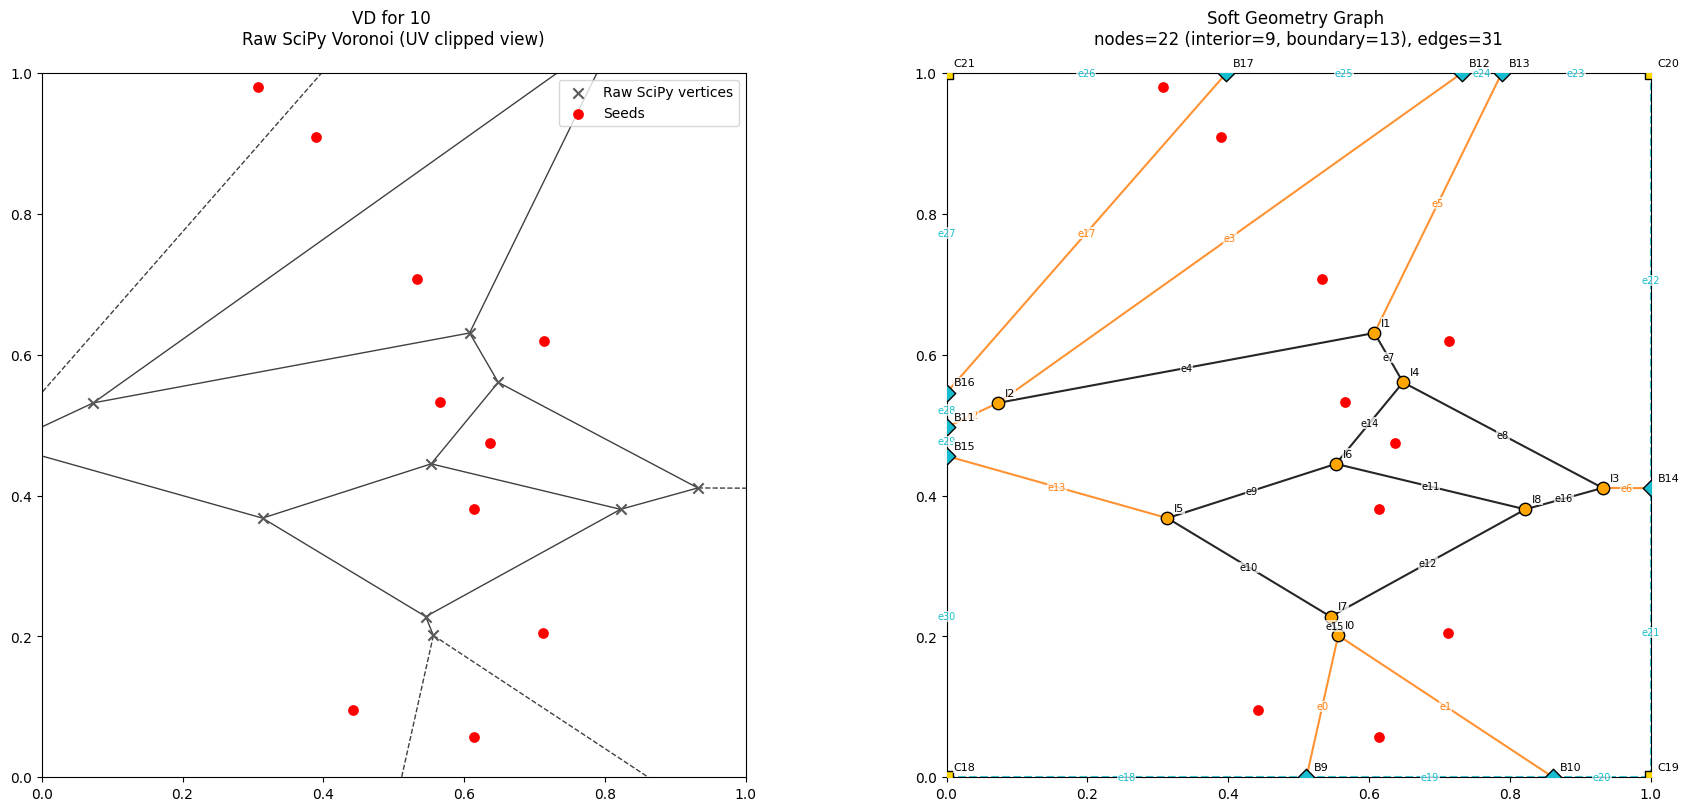


Node table
node_id  node_type       u          v      degree      alpha
      0  interior    0.556325   0.201470     3.000   1.000000
      1  interior    0.607756   0.631088     3.000   1.000000
      2  interior    0.073190   0.531780     3.000   0.999338
      3  interior    0.931970   0.410979     3.000   0.998891
      4  interior    0.648438   0.560984     3.000   1.000000
      5  interior    0.313646   0.368134     3.000   1.000000
      6  interior    0.553061   0.445177     3.000   1.000000
      7  interior    0.545459   0.228222     3.000   1.000000
      8  interior    0.822138   0.380607     3.000   1.000000
      9  boundary    0.511199   0.000000     3.000   1.000000
     10  boundary    0.861726   0.000000     3.000   1.000000
     11  boundary    0.000000   0.497551     3.000   1.000000
     12  boundary    0.731573   1.000000     3.000   1.000000
     13  boundary    0.788459   1.000000     3.000   1.000000
     14  boundary    1.000000   0.410651     3.000   1.0000

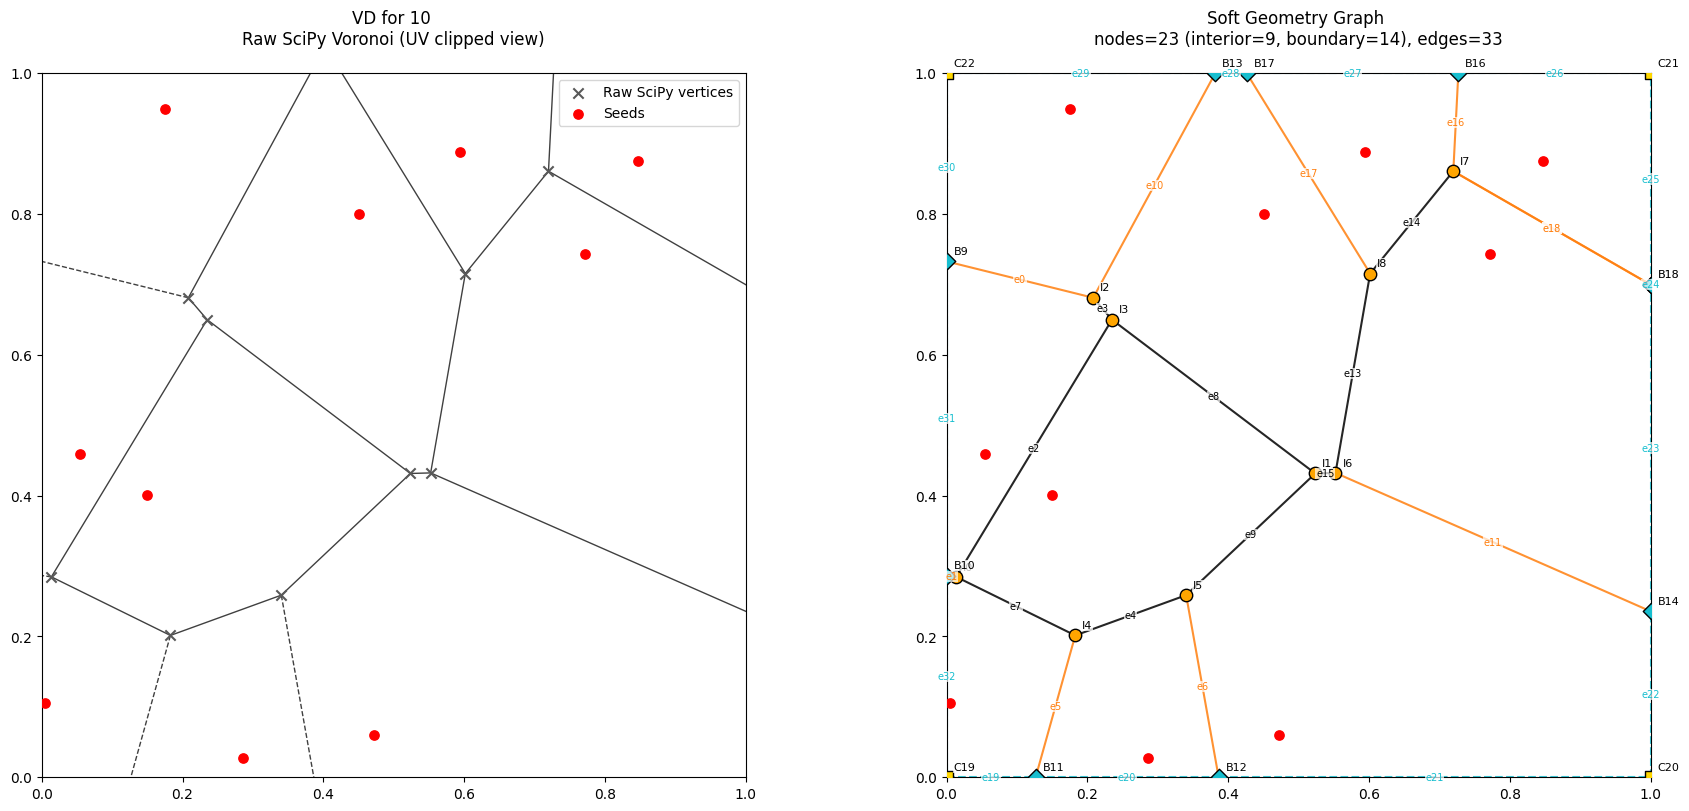


Node table
node_id  node_type       u          v      degree      alpha
      0  interior    0.013731   0.284672     3.000   0.797873
      1  interior    0.523688   0.431539     3.000   1.000000
      2  interior    0.208313   0.681132     3.000   1.000000
      3  interior    0.234993   0.650000     3.000   1.000000
      4  interior    0.182806   0.201488     3.000   1.000000
      5  interior    0.340319   0.258686     3.000   1.000000
      6  interior    0.552452   0.432341     3.000   1.000000
      7  interior    0.719811   0.860901     4.000   0.999999
      8  interior    0.601697   0.715509     3.000   1.000000
      9  boundary    0.000000   0.732778     3.000   1.000000
     10  boundary    0.000000   0.286609     3.000   1.000000
     11  boundary    0.126552   0.000000     3.000   1.000000
     12  boundary    0.386496   0.000000     3.000   1.000000
     13  boundary    0.381617   1.000000     3.000   1.000000
     14  boundary    1.000000   0.235777     3.000   1.0000

In [5]:
dec = ContinuousVoronoiDecoder(
    return_xyz=False,
    min_area=1e-3,
    duplicate_merge_sigma = 0.005,
    tau_area=1e-4,
    min_seed_dist=0.01,
    tau_close=0.001,
)

for i in range(1,4):
    N =10
    seeds = random_seeds_min_dist(
        N=N,
        min_dist=0.08,
        seed=i,
        device="cpu",
    )
    seeds = seeds.detach().clone().requires_grad_(True)

    out = dec(
        seeds,
        topology_mode="scipy",
        return_xyz=False,
    )

    graph = out["graph"]

    # print("interior vertices:", out["vertices_uv"].shape)
    # print("finite edges:", out["edges"]["edge_index"].shape)
    # print("boundary rays:", out["boundary_rays"].shape)

    # print("graph nodes:", graph["nodes_uv"].shape)
    # print("graph edges:", graph["edge_index"].shape)
    # print("node type:", graph["node_type"])
    # print("boundary nodes:", graph["num_boundary_nodes"])


    # loss = graph["nodes_uv"].sum()
    # loss.backward()
    # print("grad finite:", torch.isfinite(seeds.grad).all())

    dec.plot_scipy_vs_generated_graph(seeds,out,domain,True,True,8)



Initial seeds_uv:
tensor([[0.0043, 0.1056],
        [0.2858, 0.0270],
        [0.4716, 0.0601],
        [0.7719, 0.7437],
        [0.5944, 0.8879],
        [0.4510, 0.7995],
        [0.1498, 0.4015],
        [0.0542, 0.4594],
        [0.1756, 0.9492],
        [0.8473, 0.8749]])
Initial structure: nodes=23, edges=33, delaunay_triangles=12


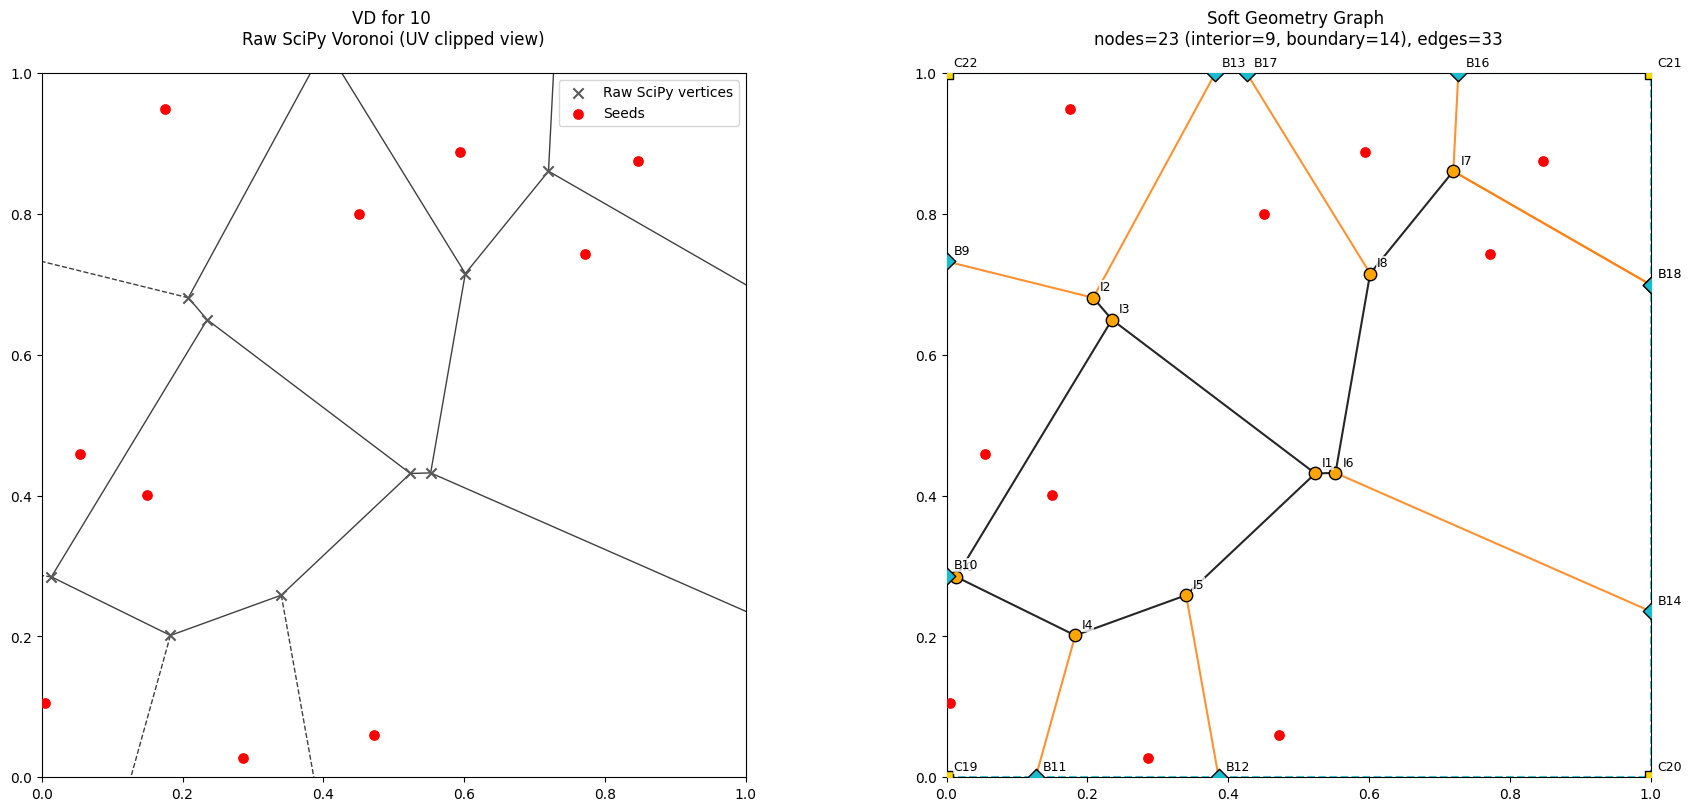

step=00 loss=1.44905492e-03 grad_norm=1.12694269e-02 nodes=23 edges=33 delaunay_triangles=12
step=01 loss=1.29934133e-03 grad_norm=1.03755286e-02 nodes=22 edges=31 delaunay_triangles=12
step=02 loss=1.16319710e-03 grad_norm=9.50876810e-03 nodes=22 edges=31 delaunay_triangles=12
step=03 loss=1.04025961e-03 grad_norm=8.67135450e-03 nodes=22 edges=31 delaunay_triangles=12
step=04 loss=9.30313254e-04 grad_norm=7.87010416e-03 nodes=22 edges=31 delaunay_triangles=12
step=05 loss=8.32887774e-04 grad_norm=7.11388886e-03 nodes=22 edges=31 delaunay_triangles=12
step=06 loss=7.47240323e-04 grad_norm=6.41530566e-03 nodes=22 edges=31 delaunay_triangles=12
step=07 loss=6.71923801e-04 grad_norm=5.78845758e-03 nodes=22 edges=31 delaunay_triangles=12
step=08 loss=6.05117413e-04 grad_norm=5.23085101e-03 nodes=22 edges=31 delaunay_triangles=12
step=09 loss=5.45367075e-04 grad_norm=4.73811291e-03 nodes=22 edges=31 delaunay_triangles=12
step=10 loss=4.91605198e-04 grad_norm=4.30309772e-03 nodes=22 edges=31

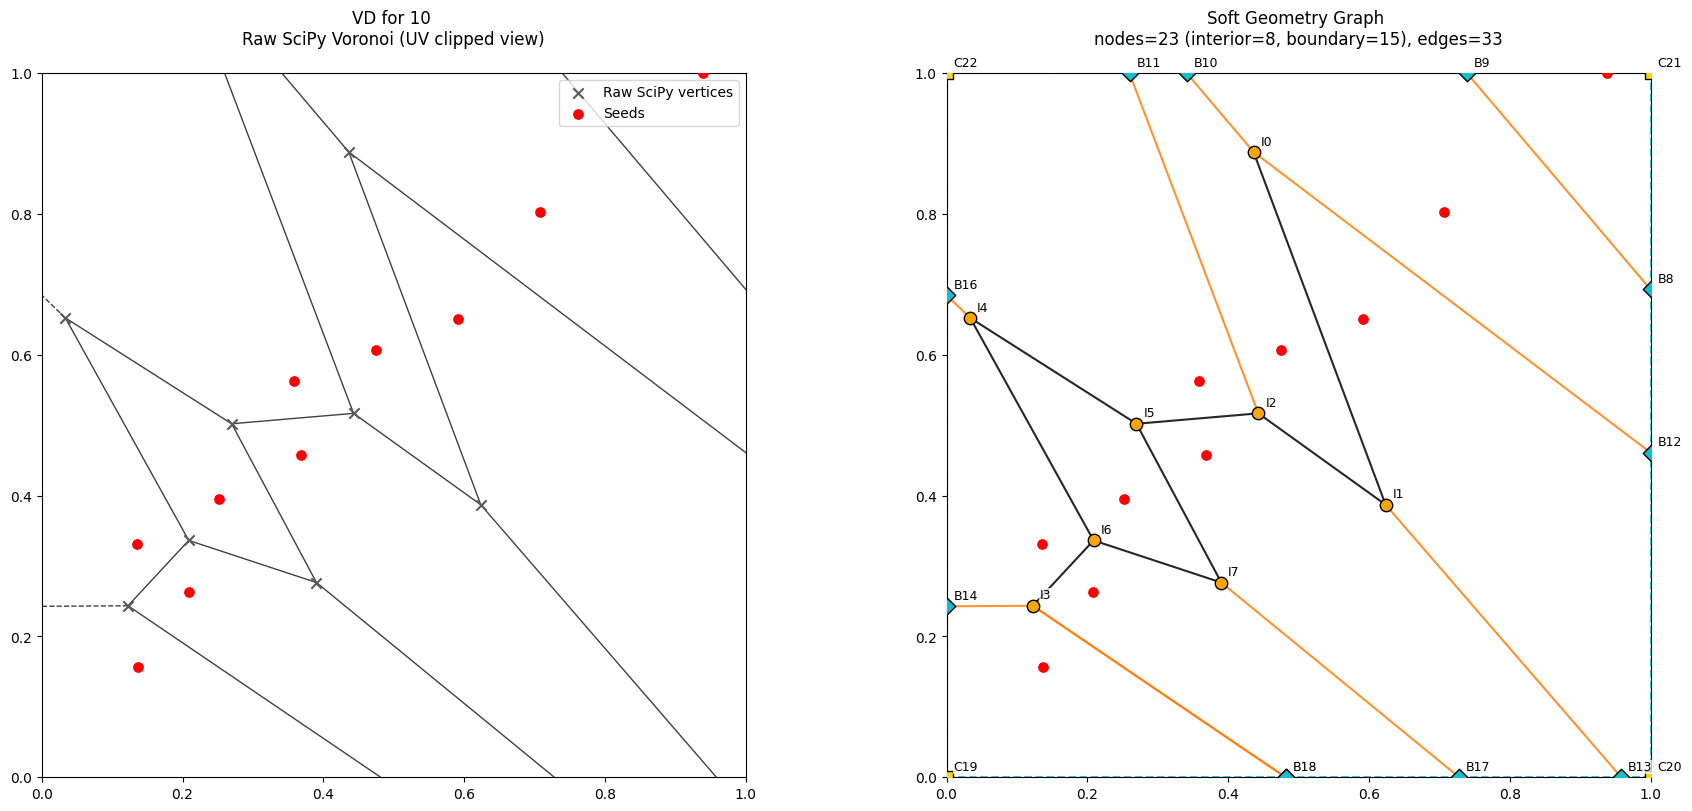

tensor([[0.1354, 0.3308],
        [0.1365, 0.1566],
        [0.2086, 0.2628],
        [0.5911, 0.6504],
        [0.7071, 0.8036],
        [0.4754, 0.6071],
        [0.3679, 0.4574],
        [0.2525, 0.3957],
        [0.3589, 0.5629],
        [0.9386, 1.0000]])


In [6]:
from tests.test_dummy_scipy_training import (
    DummyVoronoiSeedTrainer,
    irregular_test_seeds,
)

initial_seeds = irregular_test_seeds(dtype=torch.float32)
initial_seeds= seeds
trainer = DummyVoronoiSeedTrainer(
    initial_seeds,
    learning_rate=5e-3,
    edge_loss_weight=0,  # Set to 0 for area loss only
)

diagnostics = trainer.fit(steps=2000,plot_first_last=True)

trained_seeds = trainer.seeds_uv.detach()
print(trained_seeds)

In [8]:
# Edge-type-aware UV sampling keeps shell edges on the CAD boundary.
u_periodic = bool(domain["u_periodic"])
v_periodic = bool(domain["v_periodic"])

curves_uv = dec.sample_graph_edge_curves_uv(
    seeds_uv=seeds,
    graph=out["graph"],
    n_samples=128,
    u_periodic=u_periodic,
    v_periodic=v_periodic,
)
curves_xyz = dec.sample_smooth_edge_curves_xyz(Face_Cad, curves_uv)

edge_type = out["graph"]["edge_type"]
print(torch.bincount(edge_type))
print(curves_uv.shape)

curves_np = curves_xyz.detach().cpu().numpy()
plotter = pv.Plotter()
edge_colors = {0: "black", 1: "orange", 2: "gray", 3: "orange", 4: "cyan"}
for edge_id, points in enumerate(curves_np):
    polyline = pv.PolyData(points)
    polyline.lines = np.concatenate(([len(points)], np.arange(len(points)))).astype(np.int64)
    plotter.add_mesh(
        polyline,
        color="gray",
        line_width=3 if int(edge_type[edge_id]) == 4 else 2,
    )
plotter.show()


tensor([ 9, 10,  0,  0, 14])
torch.Size([33, 128, 2])


Widget(value='<iframe src="http://localhost:39773/index.html?ui=P_0x7b6a2fd7c700_2&reconnect=auto" class="pyvi…

In [9]:
# Build the voxel/FEM problem from the active continuous CAD face.
from neuraltomo_fem.run_fem_loss import NeuralTOMOFEM

tube_radius = 0.1  # XYZ/CAD units
# Gmsh runs only on the first call; these cached tensors are reused thereafter.
shell_tensors = Face_Cad.sample_shell_tensors(mesh_size=tube_radius)
problem = ThickenShell(
    thickness=2.0 * tube_radius,
    BC_dir="x",
    Load_magnitude=0.1,  # positive total force = tension in +x
    voxel_size=tube_radius,
    extra_layers=1,
    tensors=shell_tensors,
    load_case="tensile",
)
problem.debug_voxel_stats()

fem = NeuralTOMOFEM(problem, device=device, isotropic=False)
seeds = seeds.detach().clone().requires_grad_(True)
log_radius = torch.nn.Parameter(
    dec.make_learnable_radius(tube_radius).detach().to(
        device=seeds.device, dtype=seeds.dtype
    )
)
radius = torch.nn.functional.softplus(log_radius)
elem_centers_xyz = torch.as_tensor(
    problem.elem_centers.reshape(-1, 3),
    dtype=seeds.dtype,
    device=seeds.device,
)

fields = dec.graph_tube_fem_fields(
    seeds_uv=seeds,
    cad_domain=Face_Cad,
    elem_centers_xyz=elem_centers_xyz,
    radius=radius,
    topology_mode="scipy",
    n_samples=128,
    u_periodic=Face_Cad._u_periodic,
    v_periodic=Face_Cad._v_periodic,
    tau_distance=0.02,
    tau_density=0.02,
    tau_fiber=0.02,
    rho_min=1e-3,
)

stress, compliance = fem(
    density=fields["density"],
    phi=fields["phi"],
    theta=fields["theta"],
)
loss = compliance + 0.01 * fields["density"].mean()
loss.backward()

print("loss:", loss.item())
print("field shapes:", fields["density"].shape, fields["phi"].shape, fields["theta"].shape)
print("seed grad finite:", torch.isfinite(seeds.grad).all())
print("radius grad finite:", torch.isfinite(log_radius.grad).all())
print("density range:", fields["density"].min().item(), fields["density"].max().item())

# Optional debug visualization:
# dec.plot_fem_density_and_fiber_pyvista(
#     elem_centers_xyz, fields["density"], fields["fiber"], density_threshold=0.2
# )


Info    : Clearing all models and views...
Info    : Done clearing all models and views
Info    :  - Label 'Shapes/Document' (2D)
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Circle)
Info    : [ 30%] Meshing curve 2 (BSpline)
Info    : [ 60%] Meshing curve 3 (Circle)
Info    : [ 80%] Meshing curve 4 (BSpline)
Info    : Done meshing 1D (Wall 0.000304593s, CPU 0.000405s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Cylinder, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.142174s, CPU 0.141048s)
Info    : 7811 nodes 15624 elements
Info    : Clearing all models and views...
Info    : Done clearing all models and views
=== Voxel Stats ===
brep_bbox: {'xmin': -1e-07, 'xmax': 10.0000001, 'ymin': -0.12746830751419996, 'ymax': 2.1009187367176096, 'zmin': -2.0326218088715367, 'zmax': 1.9387214085522233}
mesh: {'nelx': 105, 'nely': 27, 'nelz': 44, 'elemSize': array([0.1, 0.1, 0.1]), 'type': 'grid'}
elem_centers shape: (44, 105, 27, 3)
node_coords shape: (45, 106, 28, 3)


In [10]:
dec.plot_fem_density_and_fiber_pyvista(
    elem_centers_xyz, fields["density"], fields["fiber"], density_threshold=0.2
)

Widget(value='<iframe src="http://localhost:39773/index.html?ui=P_0x7b6a2dc12590_3&reconnect=auto" class="pyvi…